In [1]:
import os
os.chdir(r"C:\Users\KHALID\Desktop\PROJECTS\Darija-Sentiment-Analysis")
os.makedirs("models", exist_ok=True)
os.makedirs("assets/images", exist_ok=True)
print("✅ Dossier:", os.getcwd())

✅ Dossier: C:\Users\KHALID\Desktop\PROJECTS\Darija-Sentiment-Analysis


# 🤖 Notebook 02 — Baseline Model: TF-IDF + Logistic Regression
## Darija Sentiment Analysis — خالد مرجان

**Objective:** Build a fast baseline model using classical ML.

Pipeline:
1. Text preprocessing (clean Darija)
2. TF-IDF vectorization
3. Logistic Regression classifier
4. Evaluation: Accuracy, F1, Confusion Matrix
5. Error analysis

> This establishes a benchmark — the transformer model in Notebook 03 must beat this.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

os.makedirs('models', exist_ok=True)
os.makedirs('assets/images', exist_ok=True)

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data

In [3]:
df_train = pd.read_csv('data/splits/train.csv', encoding='utf-8-sig')
df_val   = pd.read_csv('data/splits/val.csv',   encoding='utf-8-sig')
df_test  = pd.read_csv('data/splits/test.csv',  encoding='utf-8-sig')

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Labels: {df_train["label"].value_counts().to_dict()}')

X_train = df_train['text'].fillna('').astype(str)
y_train = df_train['label']
X_val   = df_val['text'].fillna('').astype(str)
y_val   = df_val['label']
X_test  = df_test['text'].fillna('').astype(str)
y_test  = df_test['label']

Train: 6,031 | Val: 1,294 | Test: 1,294
Labels: {'positive': 3078, 'negative': 2844, 'neutral': 109}


## 2. Darija Preprocessing

In [4]:
def clean_darija(text):
    """Lightweight Darija cleaner for TF-IDF."""
    if not isinstance(text, str):
        return ''
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'[@#]\w+', '', text)
    # Remove Arabic diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # Normalize Arabic letters
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[ىي]', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    # Normalize repeated chars
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Remove excessive punctuation
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

# Apply
X_train_clean = X_train.apply(clean_darija)
X_val_clean   = X_val.apply(clean_darija)
X_test_clean  = X_test.apply(clean_darija)

# Show examples
print('Sample preprocessing:')
for orig, clean in zip(X_train.head(3), X_train_clean.head(3)):
    print(f'  Original : {orig[:60]}')
    print(f'  Cleaned  : {clean[:60]}')
    print()

Sample preprocessing:
  Original : 3jibtni fil klem likoltu ama leken lkolo fan
  Cleaned  : 3jibtni fil klem likoltu ama leken lkolo fan

  Original : itbarkallah alik
  Cleaned  : itbarkallah alik

  Original : 3alamiaaaaaaaaa
  Cleaned  : 3alamiaa



## 3. TF-IDF Vectorization

In [5]:
# TF-IDF with character n-grams (better for Darija mixed script)
tfidf = TfidfVectorizer(
    analyzer='char_wb',      # Character n-grams — handles Darija spelling variants
    ngram_range=(2, 5),      # Bigrams to 5-grams
    max_features=50000,
    min_df=2,
    sublinear_tf=True        # Apply log normalization
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf   = tfidf.transform(X_val_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print(f'TF-IDF vocabulary size : {len(tfidf.vocabulary_):,}')
print(f'Train matrix shape     : {X_train_tfidf.shape}')
print(f'Val matrix shape       : {X_val_tfidf.shape}')

TF-IDF vocabulary size : 50,000
Train matrix shape     : (6031, 50000)
Val matrix shape       : (1294, 50000)


## 4. Train Logistic Regression

In [6]:
clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)

clf.fit(X_train_tfidf, y_train)
print('✅ Model trained!')

# Validation performance
y_val_pred = clf.predict(X_val_tfidf)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average='weighted')

print(f'\n📊 Validation Results:')
print(f'  Accuracy  : {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'  F1 Score  : {val_f1:.4f}')
print(f'\n{classification_report(y_val, y_val_pred)}')

✅ Model trained!

📊 Validation Results:
  Accuracy  : 0.9019 (90.19%)
  F1 Score  : 0.9024

              precision    recall  f1-score   support

    negative       0.90      0.91      0.91       610
     neutral       0.41      0.46      0.43        24
    positive       0.92      0.91      0.91       660

    accuracy                           0.90      1294
   macro avg       0.74      0.76      0.75      1294
weighted avg       0.90      0.90      0.90      1294



## 5. Confusion Matrix

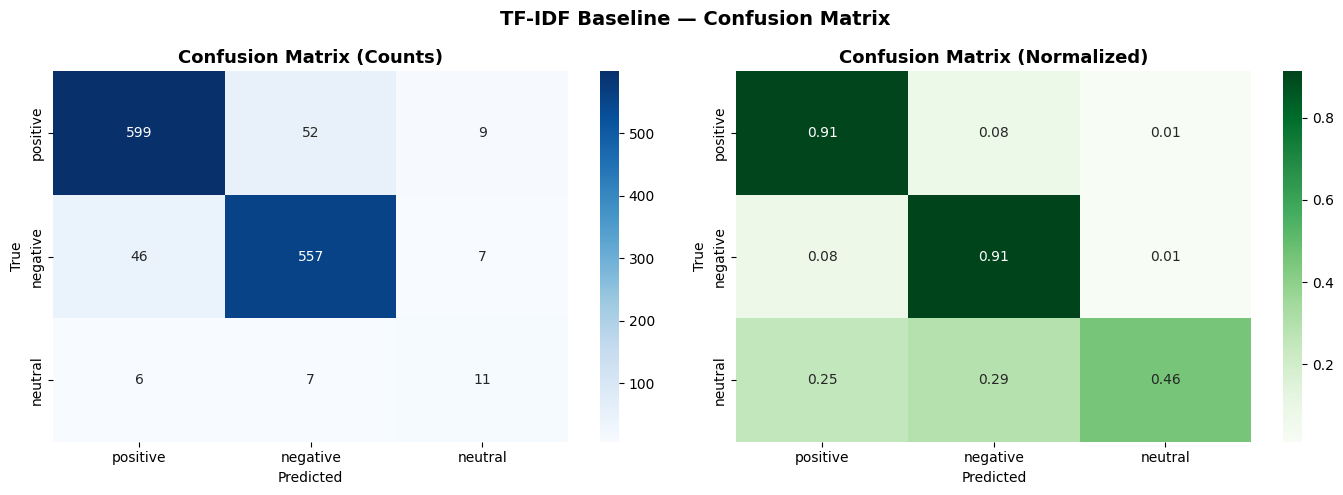

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix — counts
cm = confusion_matrix(y_val, y_val_pred, labels=['positive', 'negative', 'neutral'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'negative', 'neutral'],
            yticklabels=['positive', 'negative', 'neutral'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confusion Matrix — normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['positive', 'negative', 'neutral'],
            yticklabels=['positive', 'negative', 'neutral'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('TF-IDF Baseline — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/images/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Test Evaluation

In [8]:
y_test_pred = clf.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='weighted')

print('='*50)
print('📊 FINAL TEST RESULTS — TF-IDF Baseline')
print('='*50)
print(f'Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'F1 Score : {test_f1:.4f}')
print()
print(classification_report(y_test, y_test_pred))

📊 FINAL TEST RESULTS — TF-IDF Baseline
Accuracy : 0.9003 (90.03%)
F1 Score : 0.9008

              precision    recall  f1-score   support

    negative       0.89      0.92      0.90       610
     neutral       0.42      0.46      0.44        24
    positive       0.94      0.89      0.91       660

    accuracy                           0.90      1294
   macro avg       0.75      0.76      0.75      1294
weighted avg       0.90      0.90      0.90      1294



## 7. Error Analysis — What Did the Model Get Wrong?

In [9]:
df_errors = df_test.copy()
df_errors['predicted'] = y_test_pred
df_errors['correct']   = df_errors['label'] == df_errors['predicted']

# Show misclassified examples
errors = df_errors[~df_errors['correct']]
print(f'Total errors: {len(errors)} / {len(df_test)} ({len(errors)/len(df_test)*100:.1f}%)')
print()
print('Sample misclassifications:')
sample = errors.sample(min(10, len(errors)), random_state=42)
for _, row in sample.iterrows():
    print(f'  Text      : {str(row["text"])[:80]}')
    print(f'  True label: {row["label"]}  |  Predicted: {row["predicted"]}')
    print()

Total errors: 129 / 1294 (10.0%)

Sample misclassifications:
  Text      : بالتوفيق ، أول مرة أسمع بهذه الماركة فشكلها جميل جدااا وتنافس باقي الماركات العا
  True label: positive  |  Predicted: negative

  Text      : هاد السي وايكيكي بعد لمرات غكتجلط في الألوان اديما لحوايج ديال لكبار مكمشين،  شك
  True label: negative  |  Predicted: neutral

  Text      : راجل كبير وفاة فلوسو
  True label: negative  |  Predicted: positive

  Text      : تي زح اوول مرة نشوف قرد لاباس لينات"
  True label: negative  |  Predicted: neutral

  Text      : 3yaaan
  True label: negative  |  Predicted: positive

  Text      : قوة صوت هائلةلكن اختار الكلمات الجيدة ومن الاحسن تكون من التراث العريق التونسي م
  True label: positive  |  Predicted: negative

  Text      : احسن حاجة تصبني بيها هما الكبسولات ديال اريال غزاليين ماكينش بحالهم جربي غير وحد
  True label: positive  |  Predicted: neutral

  Text      : Snapdragon 895 😁
اما الفيديو فهو جيد و يمكن نقولو عليه سابقة ما دام تحط دقائق ب
  True label: neutral  | 

## 8. Save Model

In [10]:
# Save model and vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)

print('✅ Model saved to models/')
print()

# Quick inference test
def predict_sentiment(text):
    cleaned = clean_darija(text)
    vec = tfidf.transform([cleaned])
    label = clf.predict(vec)[0]
    proba = clf.predict_proba(vec)[0]
    classes = clf.classes_
    confidence = dict(zip(classes, proba.round(3)))
    return label, confidence

print('🧪 Quick inference test:')
test_sentences = [
    'مزيان بزاف هاد الخبر شكرا',
    'هاد الحكومة مكتخدمش والو سلبي جداً',
    'واش صحيح هاد الخبر',
    'c est vraiment bien ce projet mzyan'
]
for sentence in test_sentences:
    label, conf = predict_sentiment(sentence)
    print(f'  Text      : {sentence}')
    print(f'  Predicted : {label.upper()} | Confidence: {conf}')
    print()

print('\n➡️  Next: Run Notebook 03 — CAMeL-BERT Fine-tuning')

✅ Model saved to models/

🧪 Quick inference test:
  Text      : مزيان بزاف هاد الخبر شكرا
  Predicted : POSITIVE | Confidence: {'negative': 0.271, 'neutral': 0.041, 'positive': 0.688}

  Text      : هاد الحكومة مكتخدمش والو سلبي جداً
  Predicted : NEGATIVE | Confidence: {'negative': 0.722, 'neutral': 0.087, 'positive': 0.191}

  Text      : واش صحيح هاد الخبر
  Predicted : NEUTRAL | Confidence: {'negative': 0.349, 'neutral': 0.362, 'positive': 0.289}

  Text      : c est vraiment bien ce projet mzyan
  Predicted : NEGATIVE | Confidence: {'negative': 0.437, 'neutral': 0.135, 'positive': 0.428}


➡️  Next: Run Notebook 03 — CAMeL-BERT Fine-tuning
